In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [5]:
data = {
    'Study_Hours': [
        2, 5, 1, 6, 3, 7, 2, 4, 1, 6,
        3, 8, 2, 5, 1, 7, 4, 2, 6, 3,
        5, 1, 7, 3, 2, 8, 4, 1, 6, 2,
        3, 7, 2, 5, 1, 8, 4, 2, 6, 3
    ],

    'Sleep_Hours': [
        5, 7, 4, 8, 6, 8, 5, 7, 4, 8,
        6, 7, 5, 7, 4, 8, 6, 5, 8, 6,
        7, 4, 8, 6, 5, 8, 7, 4, 8, 5,
        6, 8, 5, 7, 4, 8, 6, 5, 8, 6
    ],

    'Social_Media_Hours': [
        6, 2, 7, 1, 5, 1, 6, 3, 8, 2,
        5, 1, 7, 3, 8, 1, 4, 6, 2, 5,
        2, 8, 1, 5, 6, 1, 3, 8, 2, 7,
        5, 1, 6, 3, 8, 1, 4, 7, 2, 5
    ],

    'Stress_Level': [
        8, 4, 9, 3, 7, 2, 8, 5, 9, 3,
        6, 2, 8, 4, 9, 2, 6, 8, 3, 7,
        4, 9, 2, 7, 8, 2, 5, 9, 3, 8,
        6, 2, 8, 4, 9, 2, 6, 8, 3, 7
    ],

    'Assignments_Pending': [
        5, 1, 6, 0, 4, 0, 5, 2, 7, 1,
        3, 0, 6, 2, 8, 0, 3, 5, 1, 4,
        1, 7, 0, 4, 5, 0, 2, 8, 1, 6,
        3, 0, 5, 2, 7, 0, 4, 6, 1, 3
    ],

    'Procrastination': [
        'Yes', 'No', 'Yes', 'No', 'Yes',
        'No', 'Yes', 'No', 'Yes', 'No',
        'Yes', 'No', 'Yes', 'No', 'Yes',
        'No', 'Yes', 'Yes', 'No', 'Yes',
        'No', 'Yes', 'No', 'Yes', 'Yes',
        'No', 'No', 'Yes', 'No', 'Yes',
        'Yes', 'No', 'Yes', 'No', 'Yes',
        'No', 'Yes', 'Yes', 'No', 'Yes'
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
   Study_Hours  Sleep_Hours  Social_Media_Hours  Stress_Level  \
0            2            5                   6             8   
1            5            7                   2             4   
2            1            4                   7             9   
3            6            8                   1             3   
4            3            6                   5             7   

   Assignments_Pending Procrastination  
0                    5             Yes  
1                    1              No  
2                    6             Yes  
3                    0              No  
4                    4             Yes  


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(40, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Study_Hours          40 non-null     int64 
 1   Sleep_Hours          40 non-null     int64 
 2   Social_Media_Hours   40 non-null     int64 
 3   Stress_Level         40 non-null     int64 
 4   Assignments_Pending  40 non-null     int64 
 5   Procrastination      40 non-null     object
dtypes: int64(5), object(1)
memory usage: 2.0+ KB
None

Statistical Summary:
       Study_Hours  Sleep_Hours  Social_Media_Hours  Stress_Level  \
count    40.000000    40.000000           40.000000     40.000000   
mean      3.950000     6.225000            4.200000      5.625000   
std       2.263988     1.440931            2.482761      2.578884   
min       1.000000     4.000000            1.000000      2.000000   
25%       2.000000     5.000000        

In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Study_Hours            0
Sleep_Hours            0
Social_Media_Hours     0
Stress_Level           0
Assignments_Pending    0
Procrastination        0
dtype: int64


In [5]:
df['Procrastination_Code'] = df['Procrastination'].map({
    'No': 0,
    'Yes': 1
})

print(df[['Procrastination', 'Procrastination_Code']].head())

  Procrastination  Procrastination_Code
0             Yes                     1
1              No                     0
2             Yes                     1
3              No                     0
4             Yes                     1


In [6]:
X = df[
    [
        'Study_Hours',
        'Sleep_Hours',
        'Social_Media_Hours',
        'Stress_Level',
        'Assignments_Pending'
    ]
]

y = df['Procrastination_Code']

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   Study_Hours  Sleep_Hours  Social_Media_Hours  Stress_Level  \
0            2            5                   6             8   
1            5            7                   2             4   
2            1            4                   7             9   
3            6            8                   1             3   
4            3            6                   5             7   

   Assignments_Pending  
0                    5  
1                    1  
2                    6  
3                    0  
4                    4  

Target:
0    1
1    0
2    1
3    0
4    1
Name: Procrastination_Code, dtype: int64


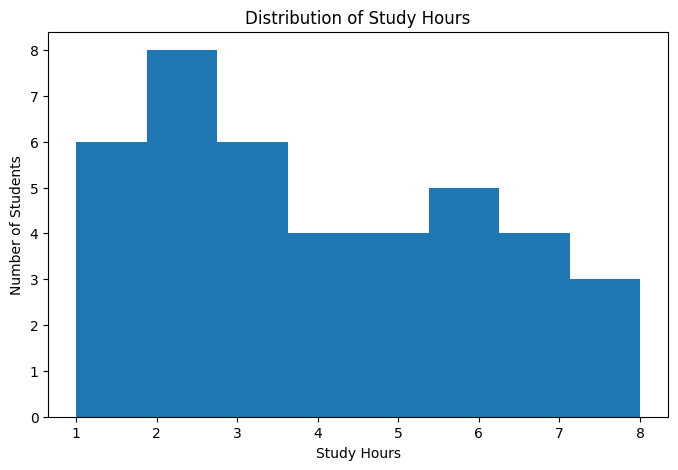

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(df['Study_Hours'], bins=8)

plt.xlabel("Study Hours")
plt.ylabel("Number of Students")
plt.title("Distribution of Study Hours")

plt.show()

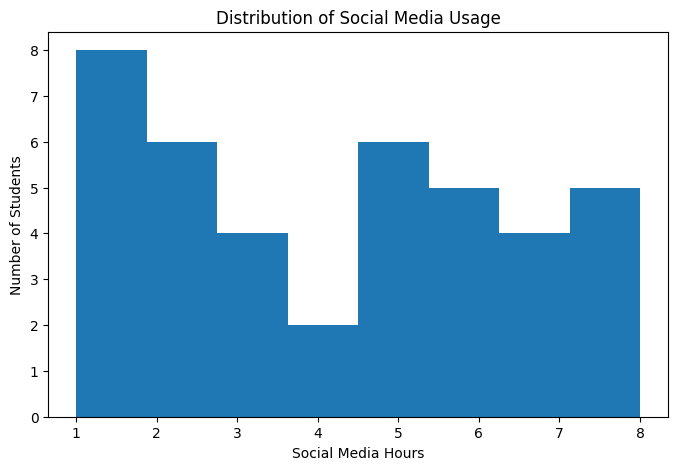

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df['Social_Media_Hours'], bins=8)

plt.xlabel("Social Media Hours")
plt.ylabel("Number of Students")
plt.title("Distribution of Social Media Usage")

plt.show()

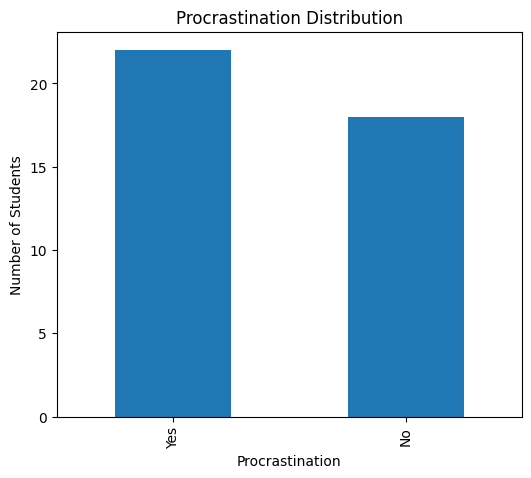

In [10]:
plt.figure(figsize=(6, 5))

df['Procrastination'].value_counts().plot(kind='bar')

plt.xlabel("Procrastination")
plt.ylabel("Number of Students")
plt.title("Procrastination Distribution")

plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (32, 5)
Testing Data: (8, 5)


In [12]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [13]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[0 0 1 1 0 1 0 1]

Predicted Values:
[0 0 1 1 0 1 0 1]


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 100.0 %


In [15]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Procrastinating', 'Procrastinating']
))

Classification Report:
                     precision    recall  f1-score   support

Not Procrastinating       1.00      1.00      1.00         4
    Procrastinating       1.00      1.00      1.00         4

           accuracy                           1.00         8
          macro avg       1.00      1.00      1.00         8
       weighted avg       1.00      1.00      1.00         8



Confusion Matrix:
[[4 0]
 [0 4]]


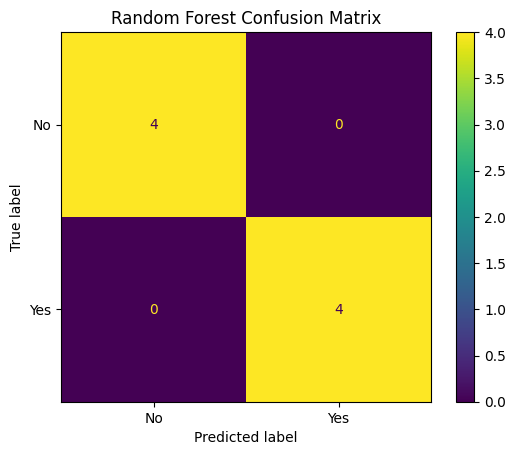

In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes']
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [17]:
importance = model.feature_importances_

feature_names = X.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

               Feature  Importance
4  Assignments_Pending        0.27
3         Stress_Level        0.26
1          Sleep_Hours        0.23
2   Social_Media_Hours        0.20
0          Study_Hours        0.04


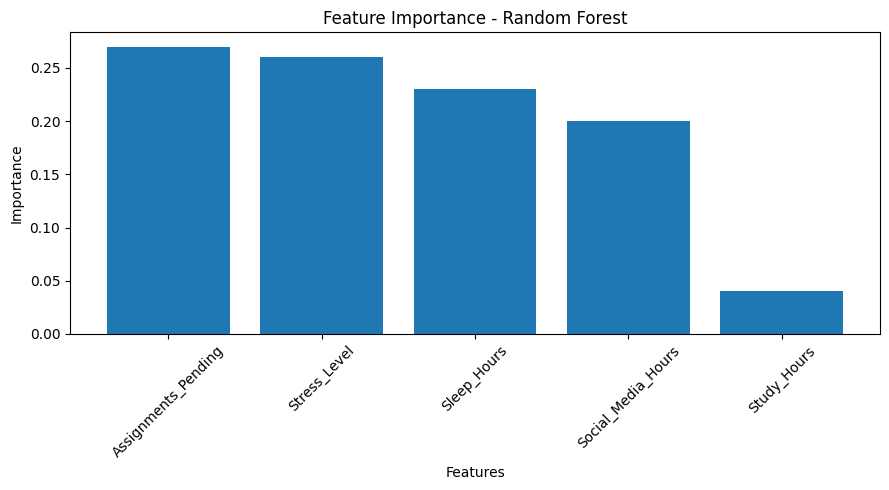

In [18]:
plt.figure(figsize=(9, 5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
new_student = pd.DataFrame({
    'Study_Hours': [3],
    'Sleep_Hours': [5],
    'Social_Media_Hours': [6],
    'Stress_Level': [8],
    'Assignments_Pending': [4]
})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Prediction: Student is likely to procrastinate.")
else:
    print("Prediction: Student is not likely to procrastinate.")

Prediction: Student is likely to procrastinate.


In [20]:
probability = model.predict_proba(new_student)

print("Probability of Not Procrastinating:",
      round(probability[0][0] * 100, 2), "%")

print("Probability of Procrastinating:",
      round(probability[0][1] * 100, 2), "%")

Probability of Not Procrastinating: 0.0 %
Probability of Procrastinating: 100.0 %


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Dataset
data = {
    'Study_Hours': [2,5,1,6,3,7,2,4,1,6,3,8,2,5,1,7,4,2,6,3,
                    5,1,7,3,2,8,4,1,6,2,3,7,2,5,1,8,4,2,6,3],

    'Sleep_Hours': [5,7,4,8,6,8,5,7,4,8,6,7,5,7,4,8,6,5,8,6,
                    7,4,8,6,5,8,7,4,8,5,6,8,5,7,4,8,6,5,8,6],

    'Social_Media_Hours': [6,2,7,1,5,1,6,3,8,2,5,1,7,3,8,1,4,6,2,5,
                           2,8,1,5,6,1,3,8,2,7,5,1,6,3,8,1,4,7,2,5],

    'Stress_Level': [8,4,9,3,7,2,8,5,9,3,6,2,8,4,9,2,6,8,3,7,
                     4,9,2,7,8,2,5,9,3,8,6,2,8,4,9,2,6,8,3,7],

    'Assignments_Pending': [5,1,6,0,4,0,5,2,7,1,3,0,6,2,8,0,3,5,1,4,
                            1,7,0,4,5,0,2,8,1,6,3,0,5,2,7,0,4,6,1,3],

    'Procrastination': [
        1,0,1,0,1,0,1,0,1,0,
        1,0,1,0,1,0,1,1,0,1,
        0,1,0,1,1,0,0,1,0,1,
        1,0,1,0,1,0,1,1,0,1
    ]
}

df = pd.DataFrame(data)

# Input features
X = df[['Study_Hours',
        'Sleep_Hours',
        'Social_Media_Hours',
        'Stress_Level',
        'Assignments_Pending']]

# Target
y = df['Procrastination']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create and train Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

# New student data
student_data = pd.DataFrame({
    'Study_Hours': [3],
    'Sleep_Hours': [5],
    'Social_Media_Hours': [6],
    'Stress_Level': [8],
    'Assignments_Pending': [4]
})

# Prediction
prediction = model.predict(student_data)

# Result
print("\n===================================")
print("   AI PROCRASTINATION PREDICTOR")
print("===================================")

if prediction[0] == 1:

    print("Prediction: PROCRASTINATING")
    print("\nAI Recommendations:")
    print("1. Reduce social media usage.")
    print("2. Create a daily study timetable.")
    print("3. Complete pending assignments.")
    print("4. Take short breaks while studying.")
    print("5. Maintain proper sleep.")

else:

    print("Prediction: NOT PROCRASTINATING")
    print("\nAI Recommendations:")
    print("1. Continue your current study routine.")
    print("2. Maintain healthy sleep habits.")
    print("3. Keep social media usage under control.")
    print("4. Complete assignments before deadlines.")

print("===================================")

Model trained successfully!

   AI PROCRASTINATION PREDICTOR
Prediction: PROCRASTINATING

AI Recommendations:
1. Reduce social media usage.
2. Create a daily study timetable.
3. Complete pending assignments.
4. Take short breaks while studying.
5. Maintain proper sleep.
